In [16]:
import os
import sys
import argparse

import seaborn as sns
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from data import *
from utils import *
from scipy import stats
from datetime import datetime
from matplotlib.patches import Rectangle
from scipy.stats import kruskal, f_oneway

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig
from TCM import compute_tcm

from BA import oh_binary_accuracy

In [17]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=5_000, help='Total # of samples') # 2_000 -> 5_000
parser.add_argument('--mb_size', type=int, default=32, help='Mini-batch size. See utils.py') # 64 -> 32; maybe 48?
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 48 -> 64; maybe 64
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=256, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=50, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=7e-05, help='Input learning rate for optimizer') # 1e-4 -> 7e-5 -> 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 100 -> 300 -> 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

In [18]:
_, xtest, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

info 0 5000 1
info 5001 10001 1


In [19]:
def kPCA(X, Y, Z, nviews=3, eps=1e-6):
    if nviews == 3:
        a = (X @ X.T + Y @ Y.T + Z @ Z.T) / nviews
    elif nviews == 2:
        a = (X @ X.T + Y @ Y.T) / nviews
    else:
        a = (X @ X.T) / nviews

    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

In [20]:
model_1V = torch.load('./out/Final-1V.tar', weights_only=False)
model_2V_IS = torch.load('./out/Final-2V-IS.tar', weights_only=False)
model_2V_IL = torch.load('./out/Final-2V-IL.tar', weights_only=False)
model_3V = torch.load('./out/Final.tar', weights_only=False)

In [21]:
# Single View Networks
net_im_en_1V = model_1V['net_im_en']
net_im_de_1V = model_1V['net_im_de']

# Two View Networks - Image + Sketch
net_im_en_2V_IS = model_2V_IS['net_im_en']
net_sk_en_2V_IS = model_2V_IS['net_sk_en']

net_im_de_2V_IS = model_2V_IS['net_im_de']
net_sk_de_2V_IS = model_2V_IS['net_sk_de']

# Two View Networks - Image + Label
net_im_en_2V_IL = model_2V_IL['net_im_en']
net_la_en_2V_IL = model_2V_IL['net_la_en']

net_im_de_2V_IL = model_2V_IL['net_im_de']
net_la_de_2V_IL = model_2V_IL['net_la_de']

# Three View Networks - Image + Sketch + Label
net_im_en_3V = model_3V['net_im_en']
net_sk_en_3V = model_3V['net_sk_en']
net_la_en_3V = model_3V['net_la_en']

net_im_de_3V = model_3V['net_im_de']
net_sk_de_3V = model_3V['net_sk_de']
net_la_de_3V = model_3V['net_la_de']

In [22]:
net_im_en_1V.eval()
net_im_en_2V_IS.eval()
net_sk_en_2V_IS.eval()
net_im_en_2V_IL.eval()
net_la_en_2V_IL.eval()
net_im_en_3V.eval()
net_sk_en_3V.eval()
net_la_en_3V.eval()

net_im_de_1V.eval()
net_im_de_2V_IS.eval()
net_sk_de_2V_IS.eval()
net_im_de_2V_IL.eval()
net_la_de_2V_IL.eval()
net_im_de_3V.eval()
net_sk_de_3V.eval()
net_la_de_3V.eval()

NetLaDe(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=128, out_features=256, bias=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (drop2): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=256, out_features=40, bias=True)
)

In [23]:
all_data_im, all_data_sk, all_data_la = [], [], []

im_en_1V = []
im_en_2V_IS, sk_en_2V_IS = [], []
im_en_2V_IL, la_en_2V_IL = [], []
im_en_3V, sk_en_3V, la_en_3V = [], [], []

im_de_1V = []
im_de_2V_IS, sk_de_2V_IS = [], []
im_de_2V_IL, la_de_2V_IL = [], []
im_de_3V, sk_de_3V, la_de_3V = [], [], []

im_loss_1V = []
im_loss_2V_IS, sk_loss_2V_IS, loss_2V_IS = [], [], []
im_loss_2V_IL, la_loss_2V_IL, loss_2V_IL = [], [], []
im_loss_3V, sk_loss_3V, la_loss_3V, loss_3V = [], [], [], []

DCI_D_1Vs, DCI_D_2V_ISs, DCI_D_2V_ILs, DCI_D_3Vs = [], [], [], []
DCI_C_1Vs, DCI_C_2V_ISs, DCI_C_2V_ILs, DCI_C_3Vs = [], [], [], []
DCI_I_1Vs, DCI_I_2V_ISs, DCI_I_2V_ILs, DCI_I_3Vs = [], [], [], []
IRS_1Vs, IRS_2V_ISs, IRS_2V_ILs, IRS_3Vs = [], [], [], []
MIG_1Vs, MIG_2V_ISs, MIG_2V_ILs, MIG_3Vs = [], [], [], []
TCM_1Vs, TCM_2V_ISs, TCM_2V_ILs, TCM_3Vs = [], [], [], []

In [24]:
recon_loss1 = torch.nn.MSELoss()
recon_loss2 = torch.nn.MSELoss()
recon_loss3 = torch.nn.BCEWithLogitsLoss()

In [25]:
with torch.no_grad():
    for i, (im, sk, la) in enumerate(xtest):
        if i > 999:
            break

        im = im.to(opt.device)
        sk = sk.to(opt.device)
        la = la.to(opt.device)

        all_data_im.append(im.cpu())
        all_data_sk.append(sk.cpu())
        all_data_la.append(la.cpu())

        # Single View
        im_en_1V.append(net_im_en_1V(im).cpu())

        # Two View - Image + Sketch
        im_en_2V_IS.append(net_im_en_2V_IS(im).cpu())
        sk_en_2V_IS.append(net_sk_en_2V_IS(sk).cpu())

        # Two View - Image + Label
        im_en_2V_IL.append(net_im_en_2V_IL(im).cpu())
        la_en_2V_IL.append(net_la_en_2V_IL(la).cpu())

        # Three View - Image + Sketch + Label
        im_en_3V.append(net_im_en_3V(im).cpu())
        sk_en_3V.append(net_sk_en_3V(sk).cpu())
        la_en_3V.append(net_la_en_3V(la).cpu())

In [26]:
all_data_im = torch.cat(all_data_im, dim=0)
all_data_sk = torch.cat(all_data_sk, dim=0)
all_data_la = torch.cat(all_data_la, dim=0)

im_en_1V = torch.cat(im_en_1V, dim=0)
im_en_2V_IS = torch.cat(im_en_2V_IS, dim=0)
sk_en_2V_IS = torch.cat(sk_en_2V_IS, dim=0)
im_en_2V_IL = torch.cat(im_en_2V_IL, dim=0)
la_en_2V_IL = torch.cat(la_en_2V_IL, dim=0)
im_en_3V = torch.cat(im_en_3V, dim=0)
sk_en_3V = torch.cat(sk_en_3V, dim=0)
la_en_3V = torch.cat(la_en_3V, dim=0)

In [27]:
def drop_constant_columns(Z, factor_types, min_per_class=10):
    valid_cols = []

    for j in range(Z.shape[1]):
        vals, counts = torch.unique(Z[:, j].long(), return_counts=True)
        count_dict = dict(zip(vals.tolist(), counts.tolist()))

        n0 = count_dict.get(0, 0)
        n1 = count_dict.get(1, 0)

        if n0 < min_per_class or n1 < min_per_class:
            print(f" > Column {j} dropped: 0={n0}, 1={n1}")
        else:
            valid_cols.append(j)

    return Z[:, valid_cols], [factor_types[j] for j in valid_cols]

In [28]:
with torch.no_grad():
    for i in range(10):
        start, stop = i * 100, (i + 1) * 100

        # Get latent representations (current batch of 100 samples)
        h_1V, _ = kPCA(im_en_1V[start:stop], None, None, nviews=1)
        h_2V_IS, _ = kPCA(im_en_2V_IS[start:stop], sk_en_2V_IS[start:stop], None, nviews=2)
        h_2V_IL, _ = kPCA(im_en_2V_IL[start:stop], la_en_2V_IL[start:stop], None, nviews=2)
        h_3V, _ = kPCA(im_en_3V[start:stop], sk_en_3V[start:stop], la_en_3V[start:stop], nviews=3)

        # Calculate U // All views
        U_1V = im_en_1V[start:stop].T @ h_1V
        U_2V_IS = im_en_2V_IS[start:stop].T @ h_2V_IS
        U_2V_IL = im_en_2V_IL[start:stop].T @ h_2V_IL
        U_3V = im_en_3V[start:stop].T @ h_3V

        # Calculate V // 2V-IS and 3V only
        V_2V_IS = sk_en_2V_IS[start:stop].T @ h_2V_IS
        V_3V = sk_en_3V[start:stop].T @ h_3V

        # Calculate W // 2V-IL and 3V only
        W_2V_IL = la_en_2V_IL[start:stop].T @ h_2V_IL
        W_3V = la_en_3V[start:stop].T @ h_3V

        # Reconstruct images, sketches, labels from latent representations
        im_1V_tilde = net_im_de_1V(h_1V @ U_1V.T)
        im_2V_IS_tilde = net_im_de_2V_IS(h_2V_IS @ U_2V_IS.T)
        im_2V_IL_tilde = net_im_de_2V_IL(h_2V_IL @ U_2V_IL.T)
        im_3V_tilde = net_im_de_3V(h_3V @ U_3V.T)

        sk_2V_IS_tilde = net_sk_de_2V_IS(h_2V_IS @ V_2V_IS.T)
        sk_3V_tilde = net_sk_de_3V(h_3V @ V_3V.T)

        la_2V_IL_tilde = net_la_de_2V_IL(h_2V_IL @ W_2V_IL.T)
        la_3V_tilde = net_la_de_3V(h_3V @ W_3V.T)

        # Calculate losses
        im_true = all_data_im[start:stop]
        sk_true = all_data_sk[start:stop]
        la_true = all_data_la[start:stop]

        im_loss_1V.append(recon_loss1(im_1V_tilde.view(im_1V_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))
        im_loss_2V_IS.append(recon_loss1(im_2V_IS_tilde.view(im_2V_IS_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))
        im_loss_2V_IL.append(recon_loss1(im_2V_IL_tilde.view(im_2V_IL_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))
        im_loss_3V.append(recon_loss1(im_3V_tilde.view(im_3V_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))

        sk_loss_2V_IS.append(recon_loss2(sk_2V_IS_tilde.view(sk_2V_IS_tilde.size(0), -1), sk_true.view(sk_true.size(0), -1)))
        sk_loss_3V.append(recon_loss2(sk_3V_tilde.view(sk_3V_tilde.size(0), -1), sk_true.view(sk_true.size(0), -1)))

        la_loss_2V_IL.append(recon_loss3(la_2V_IL_tilde.view(la_2V_IL_tilde.size(0), -1), la_true.view(la_true.size(0), -1)))
        la_loss_3V.append(recon_loss3(la_3V_tilde.view(la_3V_tilde.size(0), -1), la_true.view(la_true.size(0), -1)))

        # Store some samples for visualization
        if i == 0:
            im_de_1V.append(im_1V_tilde.cpu()[:10])
            im_de_2V_IS.append(im_2V_IS_tilde.cpu()[:10])
            im_de_2V_IL.append(im_2V_IL_tilde.cpu()[:10])
            im_de_3V.append(im_3V_tilde.cpu()[:10])
            sk_de_2V_IS.append(sk_2V_IS_tilde.cpu()[:10])
            sk_de_3V.append(sk_3V_tilde.cpu()[:10])
            la_de_2V_IL.append(la_2V_IL_tilde.cpu()[:10])
            la_de_3V.append(la_3V_tilde.cpu()[:10])


        # Disentanglement Metrics
        Z, factor_types = drop_constant_columns(la_true, ['discrete'] * la_true.shape[1], min_per_class=5)

        DCI_1V = compute_dci(h_1V, Z, factor_types, "lasso")
        DCI_2V_IS = compute_dci(h_2V_IS, Z, factor_types, "lasso")
        DCI_2V_IL = compute_dci(h_2V_IL, Z, factor_types, "lasso")
        DCI_3V = compute_dci(h_3V, Z, factor_types, "lasso")

        IRS_1V = compute_irs_from_multihot_labels(h_1V, Z)
        IRS_2V_IS = compute_irs_from_multihot_labels(h_2V_IS, Z)
        IRS_2V_IL = compute_irs_from_multihot_labels(h_2V_IL, Z)
        IRS_3V = compute_irs_from_multihot_labels(h_3V, Z)

        MIG_1V = compute_mig(h_1V, Z)
        MIG_2V_IS = compute_mig(h_2V_IS, Z)
        MIG_2V_IL = compute_mig(h_2V_IL, Z)
        MIG_3V = compute_mig(h_3V, Z)

        TCM_1V = compute_tcm(Z, h_1V)
        TCM_2V_IS = compute_tcm(Z, h_2V_IS)
        TCM_2V_IL = compute_tcm(Z, h_2V_IL)
        TCM_3V = compute_tcm(Z, h_3V)


        DCI_D_1Vs.append(DCI_1V["D"])
        DCI_D_2V_ISs.append(DCI_2V_IS["D"])
        DCI_D_2V_ILs.append(DCI_2V_IL["D"])
        DCI_D_3Vs.append(DCI_3V["D"])

        DCI_C_1Vs.append(DCI_1V["C"])
        DCI_C_2V_ISs.append(DCI_2V_IS["C"])
        DCI_C_2V_ILs.append(DCI_2V_IL["C"])
        DCI_C_3Vs.append(DCI_3V["C"])

        DCI_I_1Vs.append(DCI_1V["I"])
        DCI_I_2V_ISs.append(DCI_2V_IS["I"])
        DCI_I_2V_ILs.append(DCI_2V_IL["I"])
        DCI_I_3Vs.append(DCI_3V["I"])

        IRS_1Vs.append(IRS_1V["IRS"])
        IRS_2V_ISs.append(IRS_2V_IS["IRS"])
        IRS_2V_ILs.append(IRS_2V_IL["IRS"])
        IRS_3Vs.append(IRS_3V["IRS"])

        MIG_1Vs.append(MIG_1V["MIG"])
        MIG_2V_ISs.append(MIG_2V_IS["MIG"])
        MIG_2V_ILs.append(MIG_2V_IL["MIG"])
        MIG_3Vs.append(MIG_3V["MIG"])

        TCM_1Vs.append(TCM_1V)
        TCM_2V_ISs.append(TCM_2V_IS)
        TCM_2V_ILs.append(TCM_2V_IL)
        TCM_3Vs.append(TCM_3V)

        print(f'Batch {i + 1}/10 processed.')

 > Column 4 dropped: 0=100, 1=0
 > Column 10 dropped: 0=100, 1=0
 > Column 13 dropped: 0=96, 1=4
 > Column 14 dropped: 0=96, 1=4
 > Column 16 dropped: 0=96, 1=4
 > Column 17 dropped: 0=99, 1=1
 > Column 22 dropped: 0=96, 1=4
 > Column 35 dropped: 0=96, 1=4
Batch 1/10 processed.
 > Column 4 dropped: 0=99, 1=1
 > Column 10 dropped: 0=99, 1=1
 > Column 14 dropped: 0=97, 1=3
 > Column 15 dropped: 0=99, 1=1
 > Column 17 dropped: 0=98, 1=2
 > Column 35 dropped: 0=99, 1=1
 > Column 38 dropped: 0=97, 1=3
Batch 2/10 processed.
 > Column 4 dropped: 0=99, 1=1
 > Column 10 dropped: 0=100, 1=0
 > Column 15 dropped: 0=98, 1=2
 > Column 17 dropped: 0=97, 1=3
 > Column 22 dropped: 0=97, 1=3
 > Column 38 dropped: 0=98, 1=2
Batch 3/10 processed.
 > Column 4 dropped: 0=97, 1=3
 > Column 10 dropped: 0=99, 1=1
 > Column 35 dropped: 0=98, 1=2
Batch 4/10 processed.
 > Column 4 dropped: 0=97, 1=3
 > Column 10 dropped: 0=100, 1=0
 > Column 15 dropped: 0=96, 1=4
 > Column 26 dropped: 0=98, 1=2
Batch 5/10 proces

## Plotting

In [29]:
# Plot the losses, 4 categories on the x-axis: 1V, 2V-IS, 2V-IL, 3V; and 3 bars for each category: image, sketch, label if applicable
categories = ['1V', '2V-IS', '2V-IL', '3V']

im_losses = [
    torch.stack(im_loss_1V).mean(),
    torch.stack(im_loss_2V_IS).mean(),
    torch.stack(im_loss_2V_IL).mean(),
    torch.stack(im_loss_3V).mean()
]

sk_losses = [
    None,
    torch.stack(sk_loss_2V_IS).mean(),
    None,
    torch.stack(sk_loss_3V).mean()
]

la_losses = [
    None,
    None,
    torch.stack(la_loss_2V_IL).mean(),
    torch.stack(la_loss_3V).mean()
]

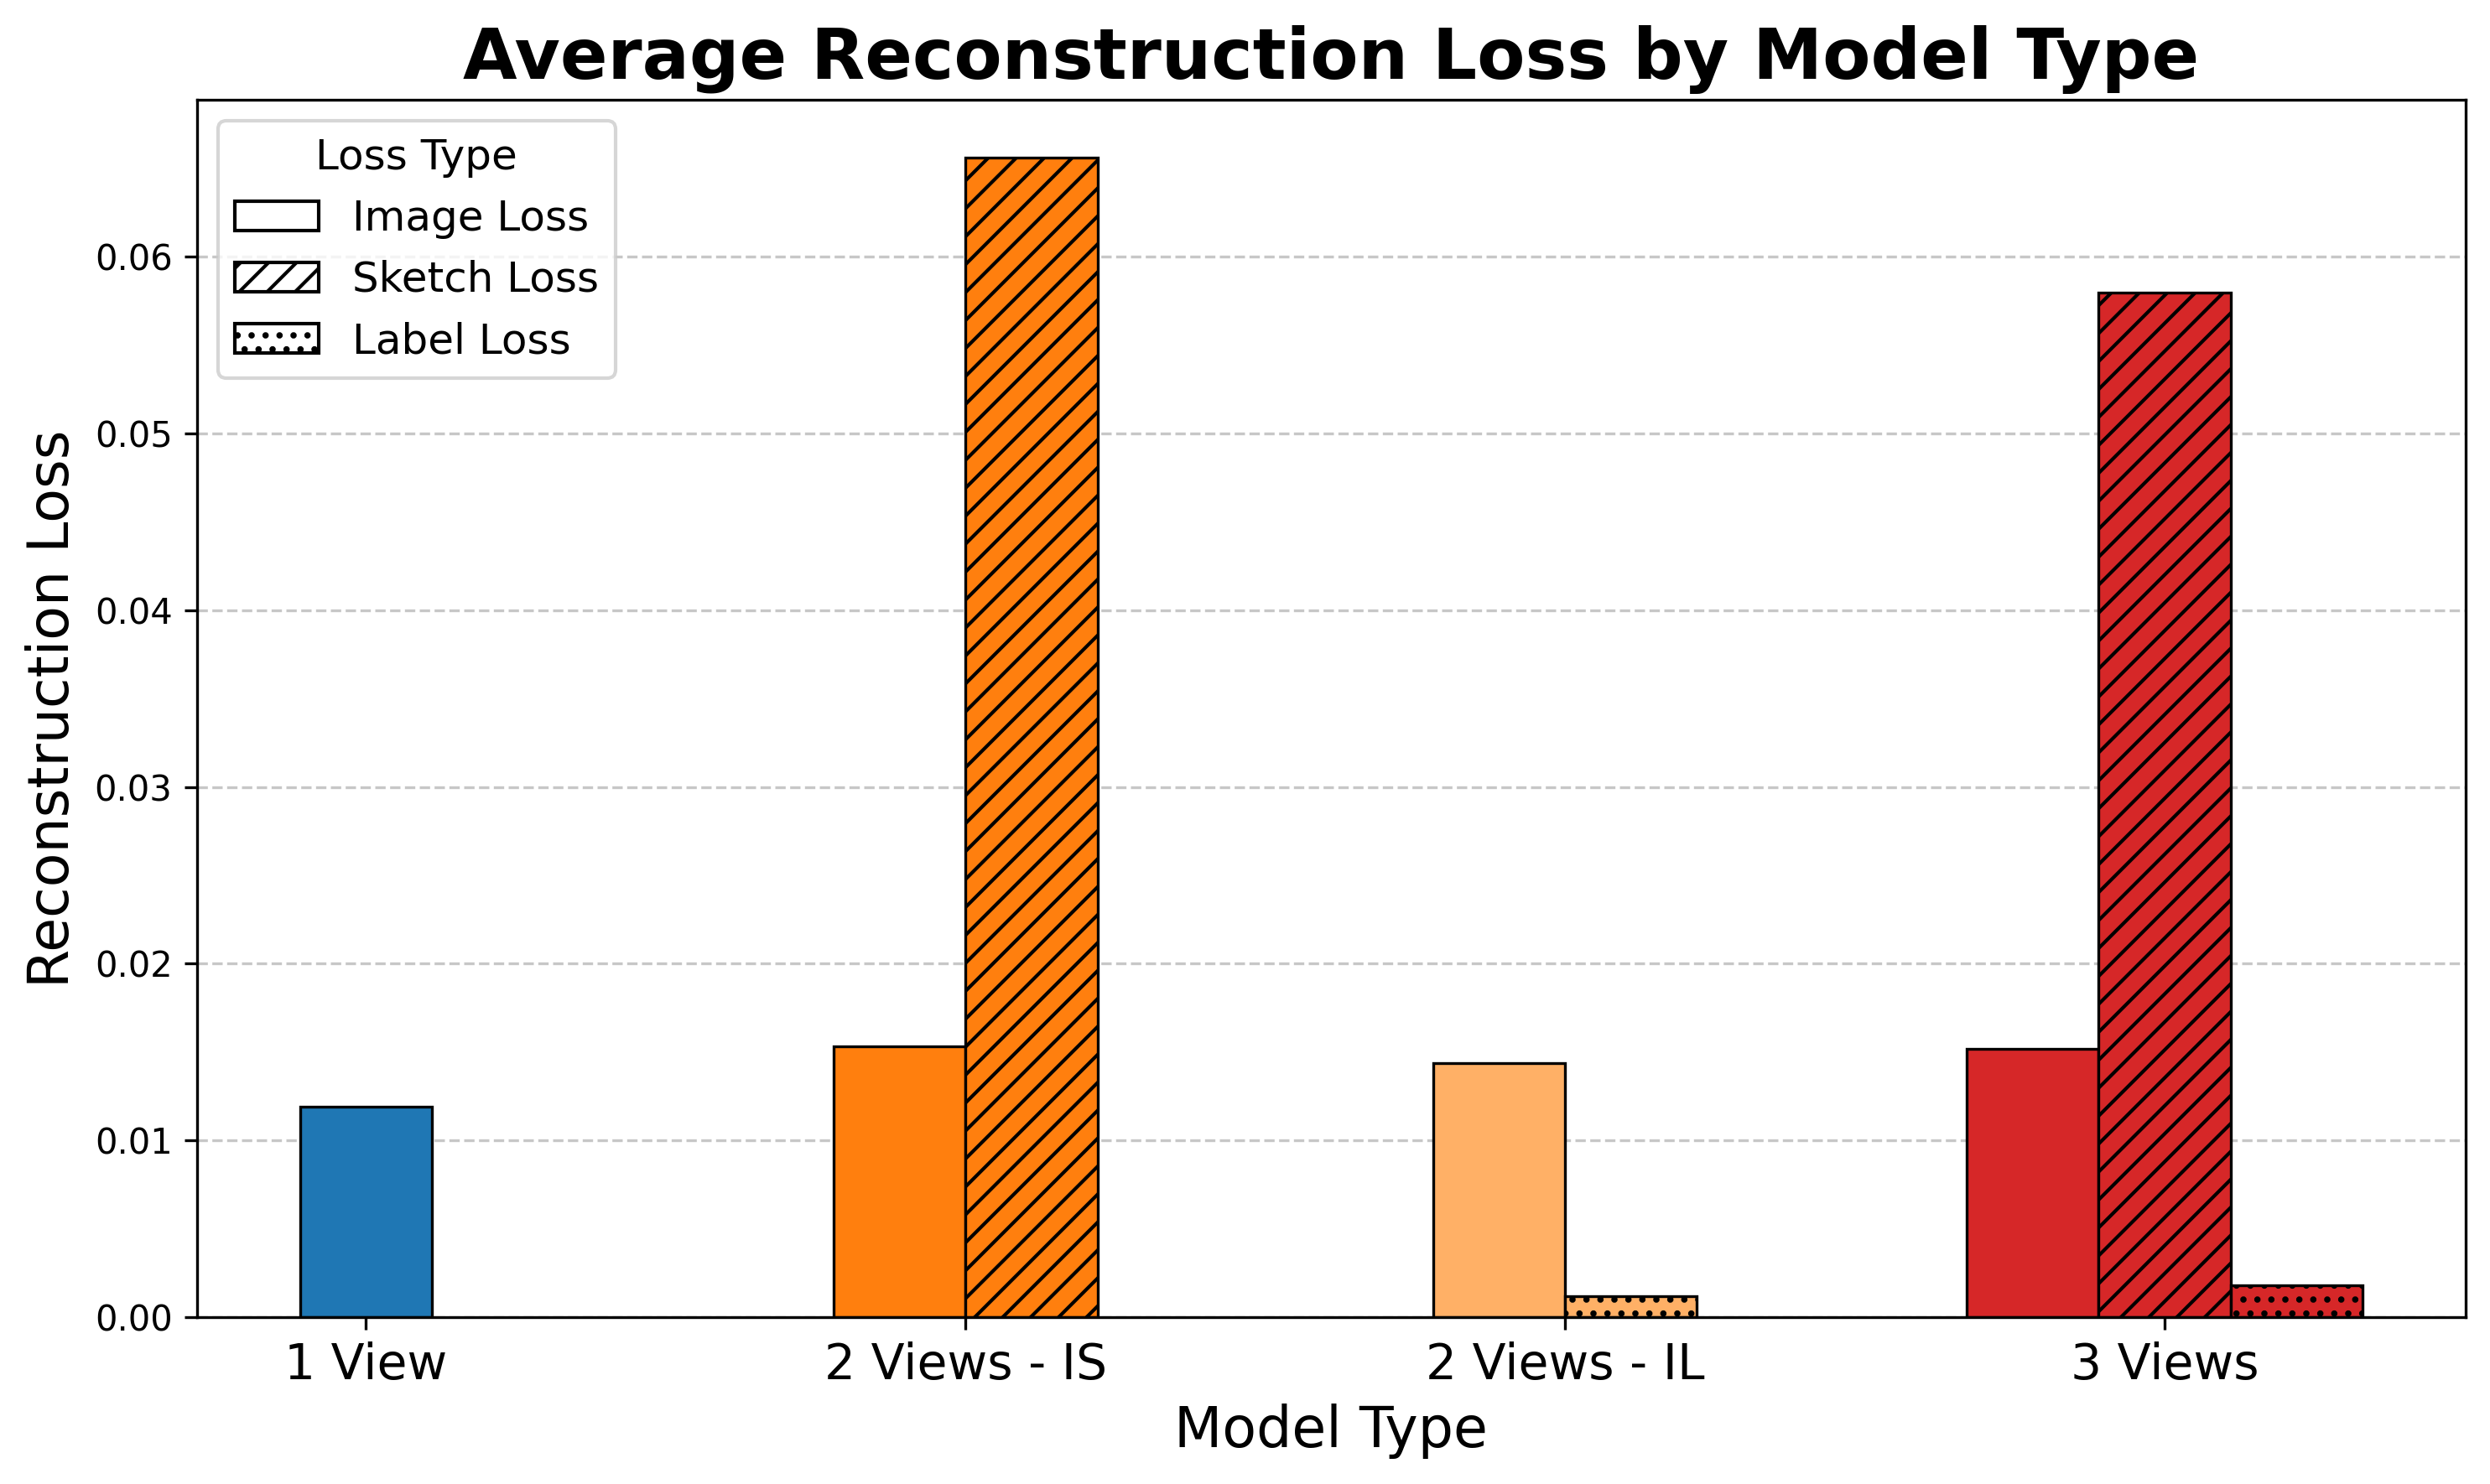

In [30]:
categories = ['1 View', '2 Views - IS', '2 Views - IL', '3 Views']
x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.22

model_color_map = {
    '1 View': 'tab:blue',
    '2 Views - IS': 'tab:orange',
    '2 Views - IL': '#ffb066',
    '3 Views': 'tab:red'
}

hatch_map = {
    'Image Loss': '',
    'Sketch Loss': '///',
    'Label Loss': '...'
}

for i, cat in enumerate(categories):
    bars = [('Image Loss', im_losses[i].item())]

    if cat in ['2 Views - IS', '3 Views']:
        bars.append(('Sketch Loss', sk_losses[i].item()))

    if cat in ['2 Views - IL', '3 Views']:
        bars.append(('Label Loss', la_losses[i].item()))

    n = len(bars)

    if n == 1:
        offsets = [0]
    elif n == 2:
        offsets = [-bar_width / 2, bar_width / 2]
    else:
        offsets = [-bar_width, 0, bar_width]

    for offset, (label, value) in zip(offsets, bars):
        ax.bar(
            x[i] + offset,
            value,
            bar_width,
            color=model_color_map[cat],
            hatch=hatch_map[label],
            edgecolor='black',
            linewidth=0.8
        )

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=14)
ax.set_xlabel('Model Type', fontsize=16)
ax.set_ylabel('Reconstruction Loss', fontsize=16)

plt.title('Average Reconstruction Loss by Model Type', fontsize=20, fontweight='bold')

legend_handles = [
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Image Loss'],
        label='Image Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Sketch Loss'],
        label='Sketch Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Label Loss'],
        label='Label Loss'
    )
]

ax.legend(
    handles=legend_handles,
    title='Loss Type',
    loc='upper left',
    fontsize=12,
    title_fontsize=12
)

ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./img/reconstruction_loss_comparison.png', dpi=300)
plt.show()

In [31]:
print(f'---- 1V Losses ----')
print(f' > Image Loss: {im_losses[0].item():.6f}')
print()
print(f'---- 2V-IS Losses ----')
print(f' > Image Loss: {im_losses[1].item():.6f}')
print(f' > Sketch Loss: {sk_losses[1].item():.6f}')
print()
print(f'---- 2V-IL Losses ----')
print(f' > Image Loss: {im_losses[2].item():.6f}')
print(f' > Label Loss: {la_losses[2].item():.6f}')
print()
print(f'---- 3V Losses ----')
print(f' > Image Loss: {im_losses[3].item():.6f}')
print(f' > Sketch Loss: {sk_losses[3].item():.6f}')
print(f' > Label Loss: {la_losses[3].item():.6f}')

---- 1V Losses ----
 > Image Loss: 0.011886

---- 2V-IS Losses ----
 > Image Loss: 0.015343
 > Sketch Loss: 0.065581

---- 2V-IL Losses ----
 > Image Loss: 0.014399
 > Label Loss: 0.001195

---- 3V Losses ----
 > Image Loss: 0.015168
 > Sketch Loss: 0.057943
 > Label Loss: 0.001822


## Statistical tests
**Null Hypothesis**: There is no difference in mean between the four groups

In [32]:
# TEst for normality of the losses using Shapiro-Wilk test
print('Shapiro-Wilk Test for Normality of Image Losses:')
for i, cat in enumerate(categories):
    if cat == '1V':
        stat, p = stats.shapiro(torch.stack(im_loss_1V).cpu().numpy())
    elif cat == '2V-IS':
        stat, p = stats.shapiro(torch.stack(im_loss_2V_IS).cpu().numpy())
    elif cat == '2V-IL':
        stat, p = stats.shapiro(torch.stack(im_loss_2V_IL).cpu().numpy())
    else:  # cat == '3V'
        stat, p = stats.shapiro(torch.stack(im_loss_3V).cpu().numpy())

    print(f' > {cat}: W-statistic = {stat:.4f}, p-value = {p:.4e}')
    print(f'   > Nomrality: {p>0.05}\n')

Shapiro-Wilk Test for Normality of Image Losses:
 > 1 View: W-statistic = 0.9223, p-value = 3.7646e-01
   > Nomrality: True

 > 2 Views - IS: W-statistic = 0.9223, p-value = 3.7646e-01
   > Nomrality: True

 > 2 Views - IL: W-statistic = 0.9223, p-value = 3.7646e-01
   > Nomrality: True

 > 3 Views: W-statistic = 0.9223, p-value = 3.7646e-01
   > Nomrality: True



In [33]:
# Perform an ANOVA oneway test
anova_im = f_oneway(
    torch.stack(im_loss_1V).cpu().numpy(),
    torch.stack(im_loss_2V_IS).cpu().numpy(),
    torch.stack(im_loss_2V_IL).cpu().numpy(),
    torch.stack(im_loss_3V).cpu().numpy()
)

print(f'ANOVA Oneway Test for Image Losses: F-statistic = {anova_im.statistic:.4f}, p-value = {anova_im.pvalue:.4e}')

ANOVA Oneway Test for Image Losses: F-statistic = 64.2846, p-value = 1.5679e-14


$p$-value $< 0.05$ => Reject Null hypothesis, concluding there is a difference between the four groups

In [34]:
im_loss_data = [
    torch.stack(im_loss_1V).cpu().numpy(),
    torch.stack(im_loss_2V_IS).cpu().numpy(),
    torch.stack(im_loss_2V_IL).cpu().numpy(),
    torch.stack(im_loss_3V).cpu().numpy()
]

tukey_results = sp.posthoc_tukey(im_loss_data)

1    a  
2     b 
3      c
4     b 
Name: letters, dtype: object
              1             2             3             4
1  1.000000e+00  1.073586e-13  6.926898e-10  5.125900e-13
2  1.073586e-13  1.000000e+00  9.783499e-03  9.249930e-01
3  6.926898e-10  9.783499e-03  1.000000e+00  4.567600e-02
4  5.125900e-13  9.249930e-01  4.567600e-02  1.000000e+00


/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_13185/1773434525.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


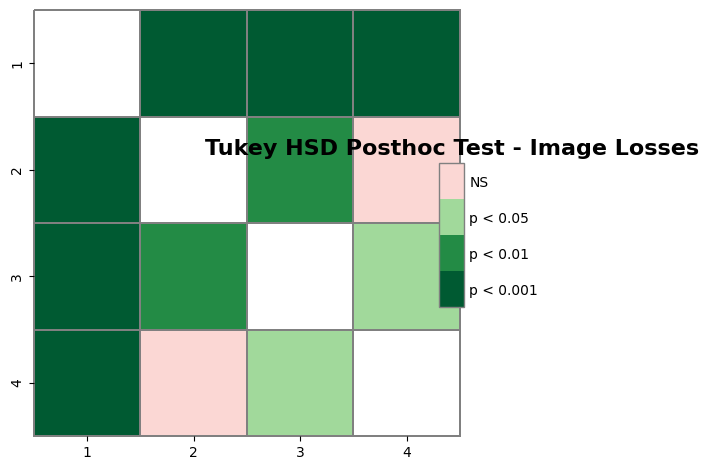

In [35]:
heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}

sp.sign_plot(tukey_results, **heatmap_args)
plt.title('Tukey HSD Posthoc Test - Image Losses', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('./img/turkey_posthoc_image_loss.png', dpi=300)

print(sp.compact_letter_display(tukey_results)) 
print(tukey_results)

## Boxplot

In [36]:
df = pd.DataFrame({
    "loss": (
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_1V] +
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_2V_IS] +
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_2V_IL] +
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_3V]
    ),
    "model": (
        ["1 Views"] * len(im_loss_1V) +
        ["2 Views - IS"] * len(im_loss_2V_IS) +
        ["2 Views - IL"] * len(im_loss_2V_IL) +
        ["3 Views"] * len(im_loss_3V)
    )
})

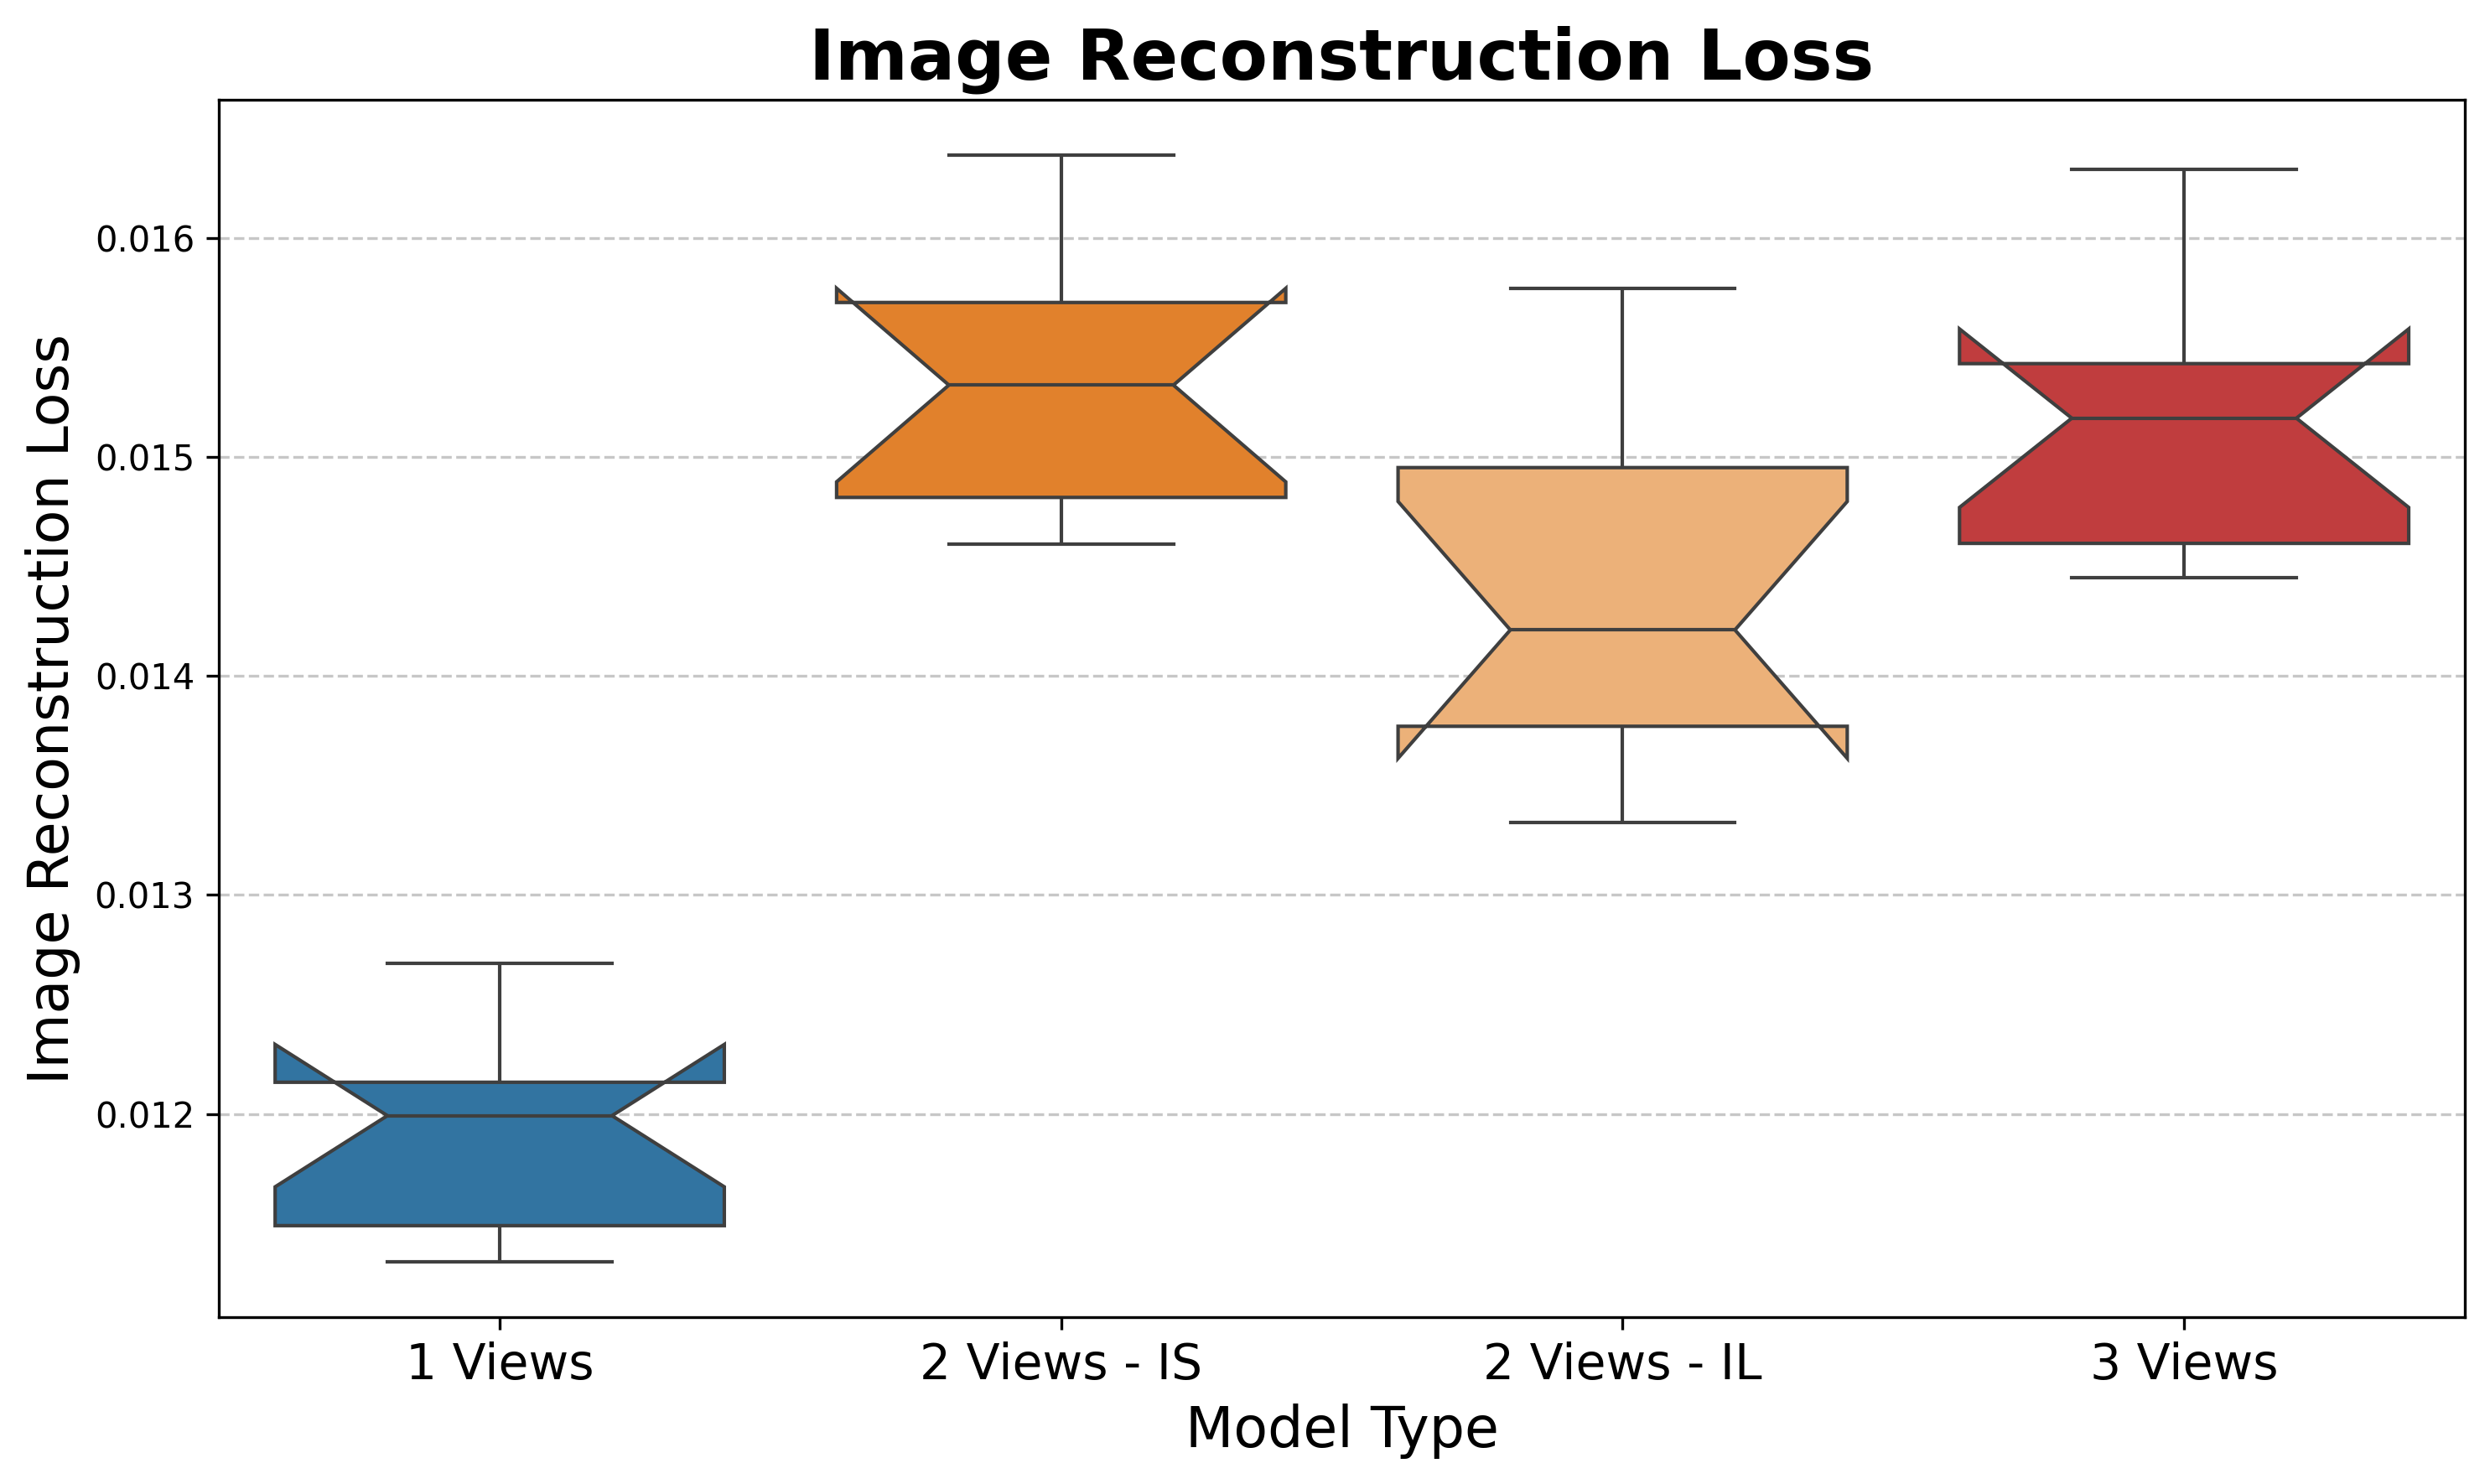

In [37]:
plt.figure(figsize=(10, 6), dpi=300)

sns.boxplot(data=df, x="model", y="loss", notch=True, palette=['tab:blue', 'tab:orange', '#ffb066', 'tab:red'], hue="model")

plt.xlabel("Model Type", fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel("Image Reconstruction Loss", fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Image Reconstruction Loss", fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('./img/image_reconstruction_loss_boxplot.png', dpi=300)
plt.show()

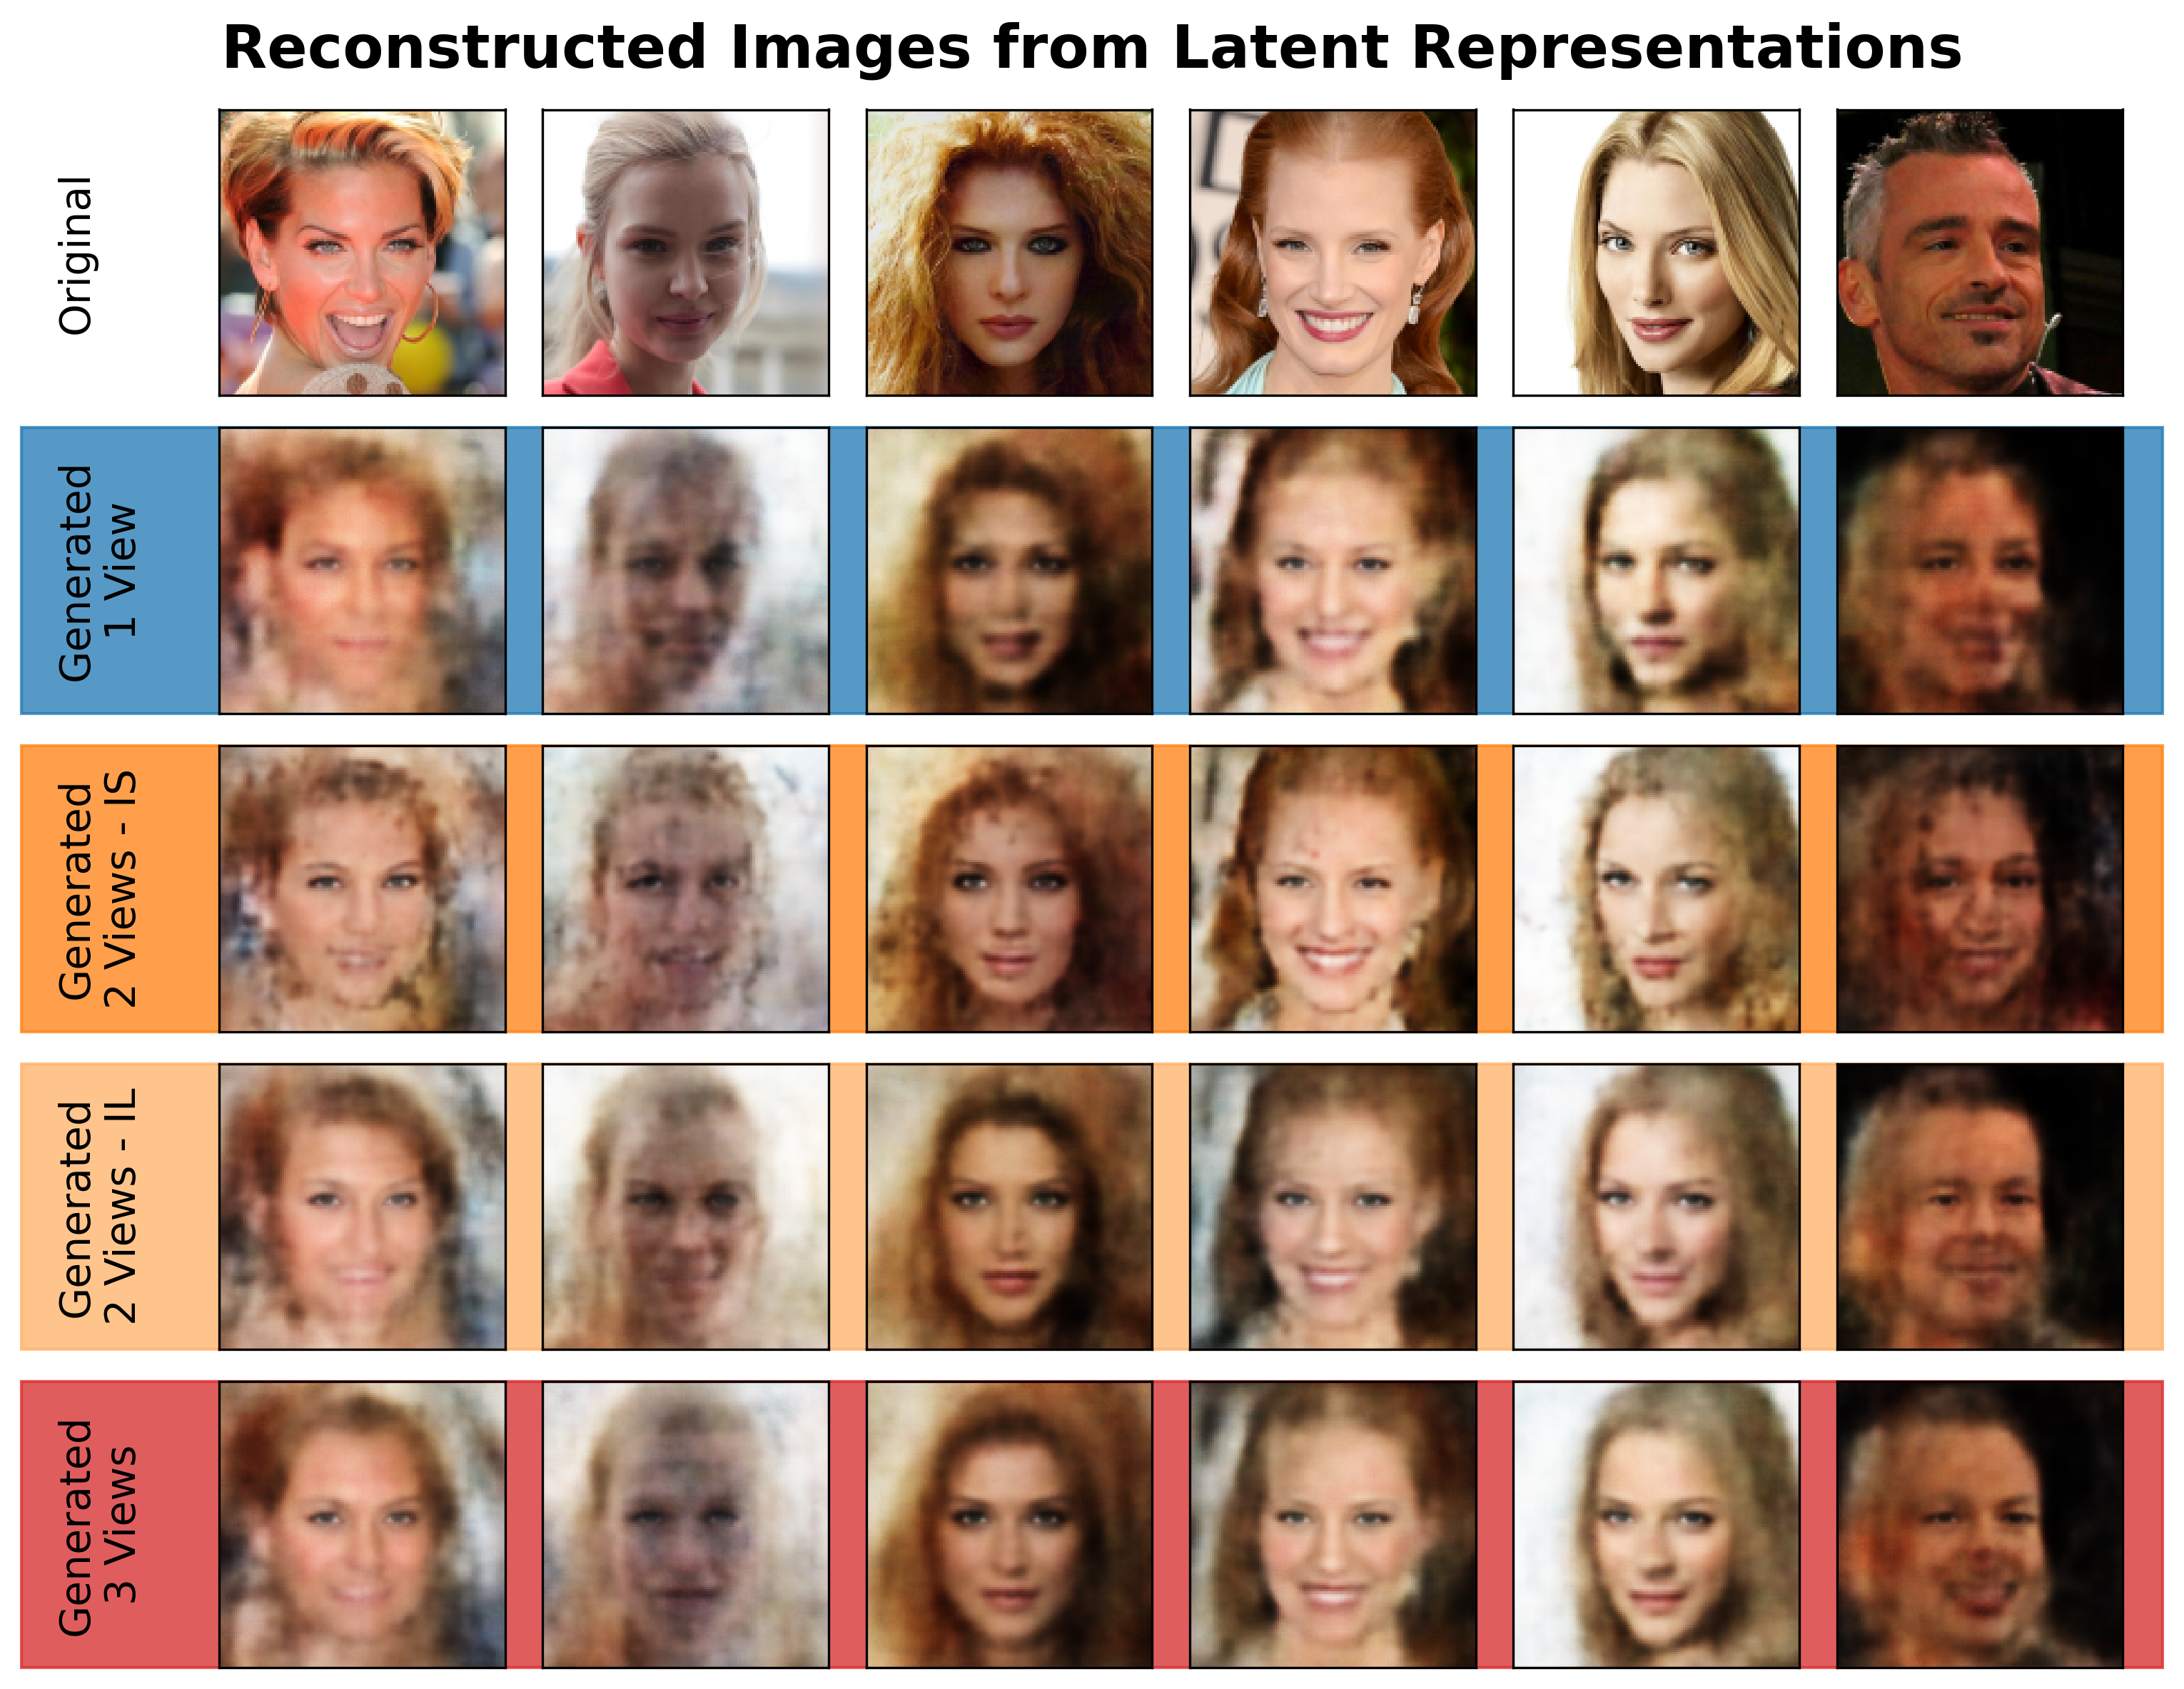

In [38]:
fig, ax = plt.subplots(5, 6, figsize=(10, 8), dpi=300)

for i in range(5):
    for j in range(6):
        if i == 0:
            img = all_data_im[j].permute(1, 2, 0).numpy()
        elif i == 1:
            img = im_de_1V[0][j].permute(1, 2, 0).numpy()
        elif i == 2:
            img = im_de_2V_IS[0][j].permute(1, 2, 0).numpy()
        elif i == 3:
            img = im_de_2V_IL[0][j].permute(1, 2, 0).numpy()
        else:
            img = im_de_3V[0][j].permute(1, 2, 0).numpy()

        ax[i, j].imshow(img)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    if i == 0:
        ax[i, 0].set_ylabel('Original\n', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 1:
        ax[i, 0].set_ylabel('Generated\n1 View', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 2:
        ax[i, 0].set_ylabel('Generated\n2 Views - IS', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 3:
        ax[i, 0].set_ylabel('Generated\n2 Views - IL', fontsize=14, rotation=90, labelpad=40, va='center')
    else:
        ax[i, 0].set_ylabel('Generated\n3 Views', fontsize=14, rotation=90, labelpad=40, va='center')

plt.suptitle('Reconstructed Images from Latent Representations', fontsize=20, fontweight='bold')
plt.tight_layout()
row_colors = [None, 'tab:blue', 'tab:orange', '#ffb066', 'tab:red']

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )



plt.savefig('./img/reconstructed_images_comparison.png', dpi=300)
plt.show()

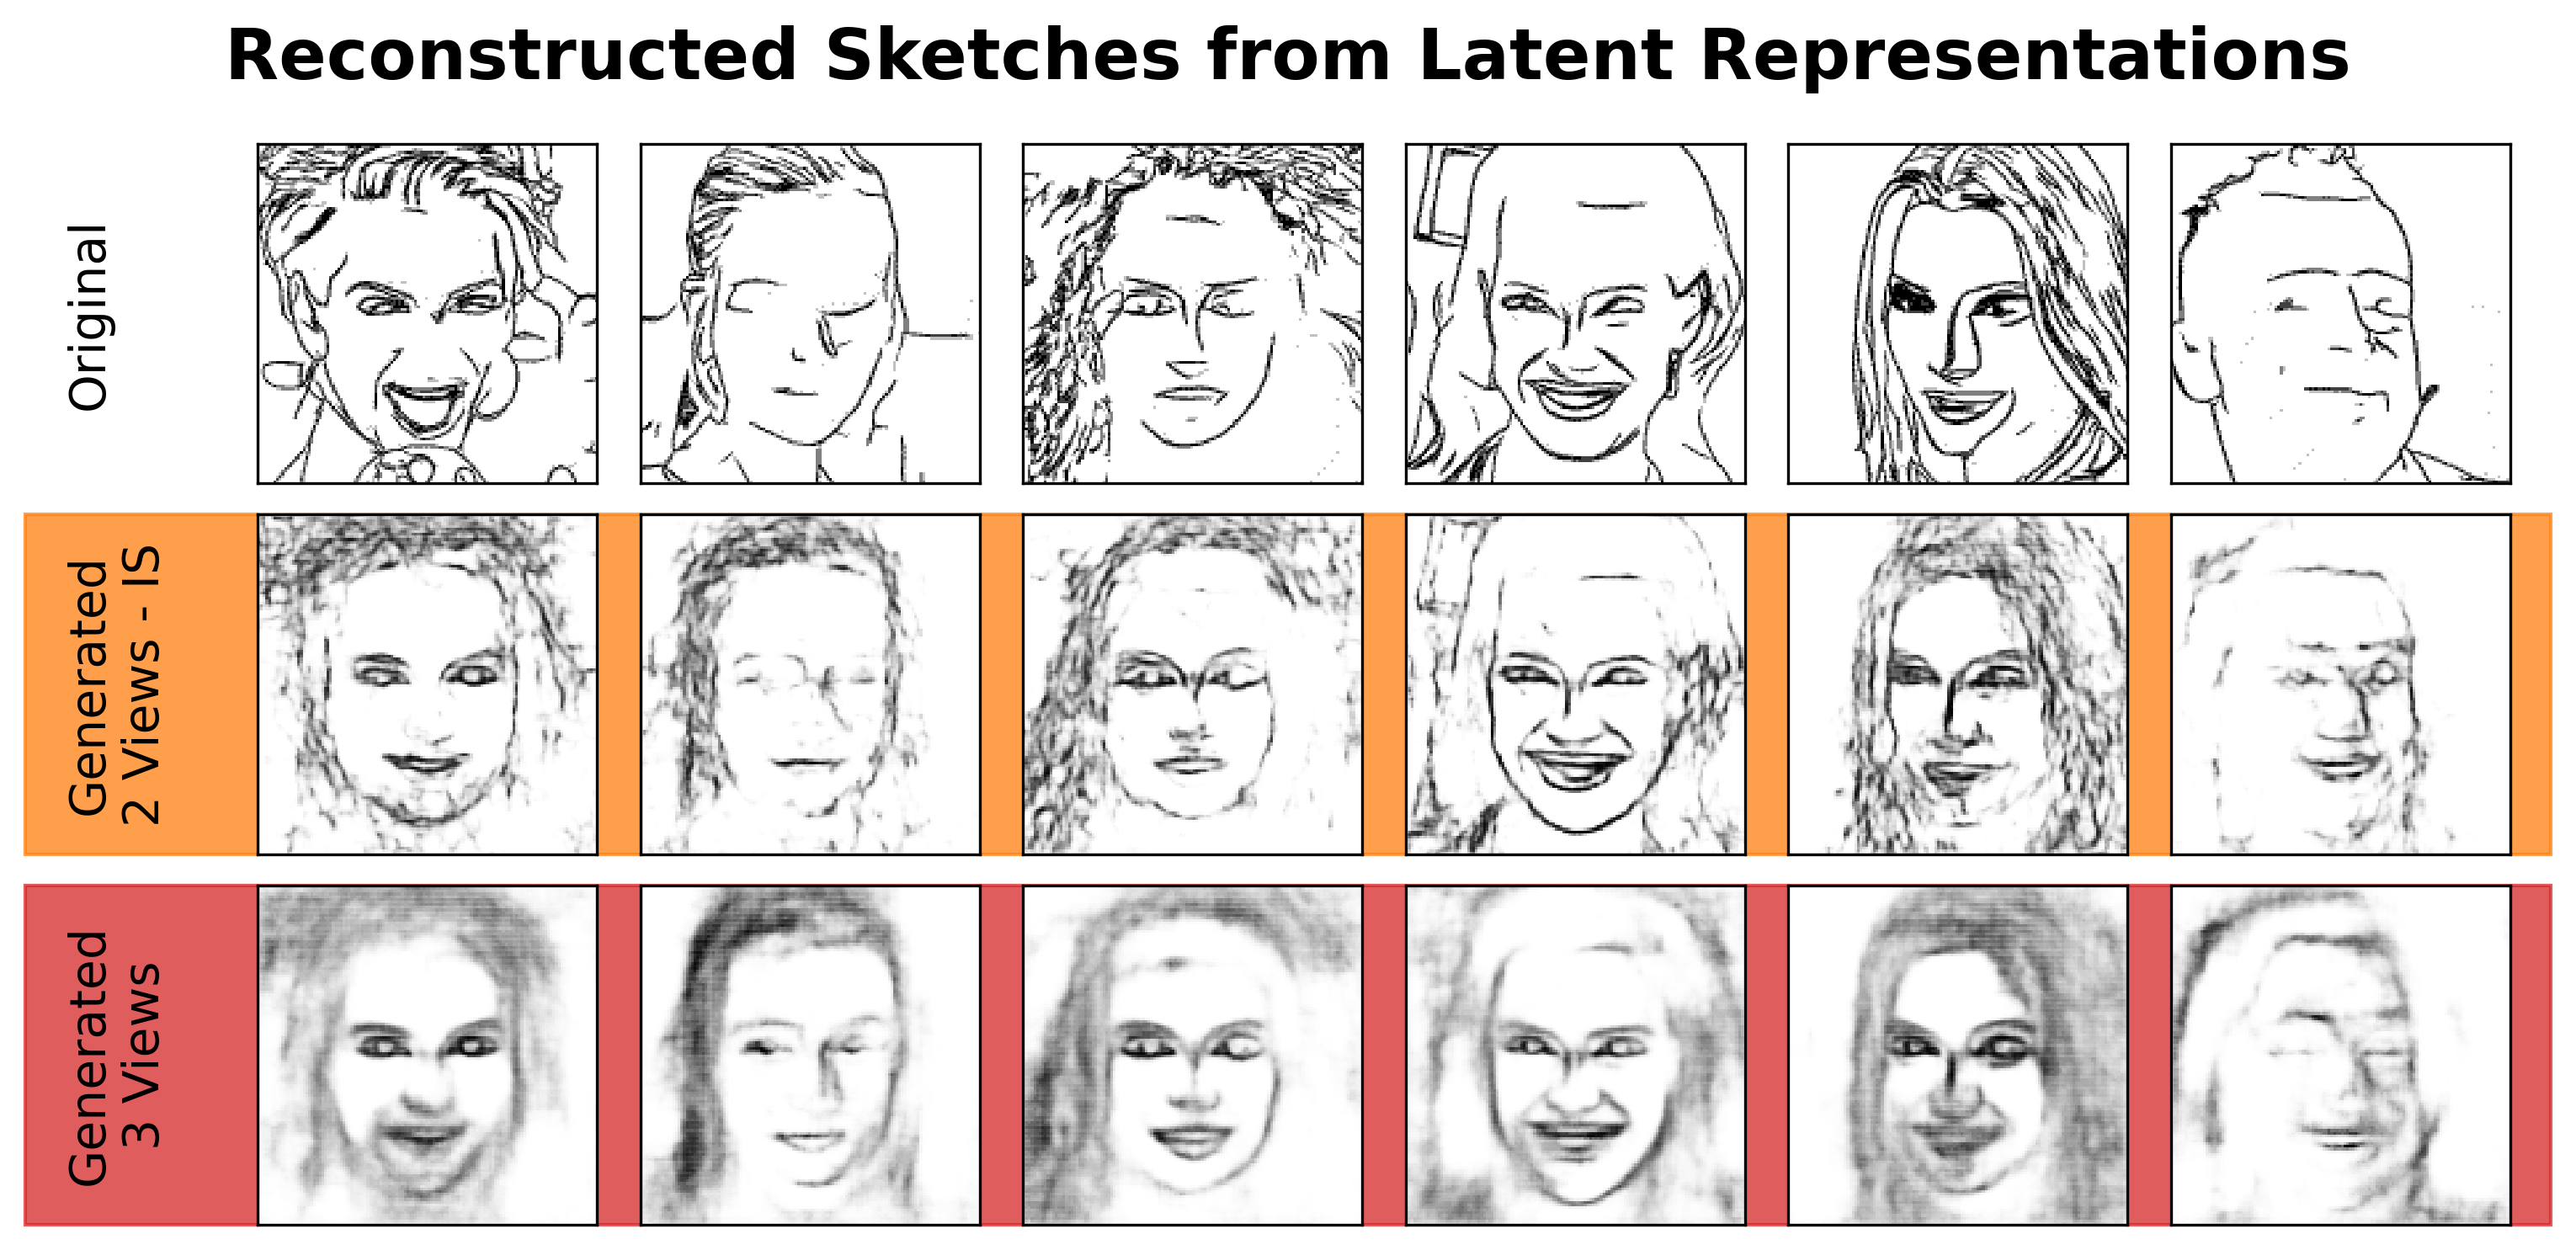

In [39]:
fig, ax = plt.subplots(3, 6, figsize=(10, 5), dpi=300)

for i in range(3):
    for j in range(6):
        if i == 0:
            img = all_data_sk[j].permute(1, 2, 0).numpy()
        elif i == 1:
            img = sk_de_2V_IS[0][j].permute(1, 2, 0).numpy()
        elif i == 2:
            img = sk_de_3V[0][j].permute(1, 2, 0).numpy()

        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    if i == 0:
        ax[i, 0].set_ylabel('Original\n', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 1:
        ax[i, 0].set_ylabel('Generated\n2 Views - IS', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 2:
        ax[i, 0].set_ylabel('Generated\n3 Views', fontsize=14, rotation=90, labelpad=40, va='center')

plt.suptitle('Reconstructed Sketches from Latent Representations', fontsize=20, fontweight='bold')
plt.tight_layout()
row_colors = [None, 'tab:orange', 'tab:red']

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )



plt.savefig('./img/reconstructed_sketches_comparison.png', dpi=300)
plt.show()

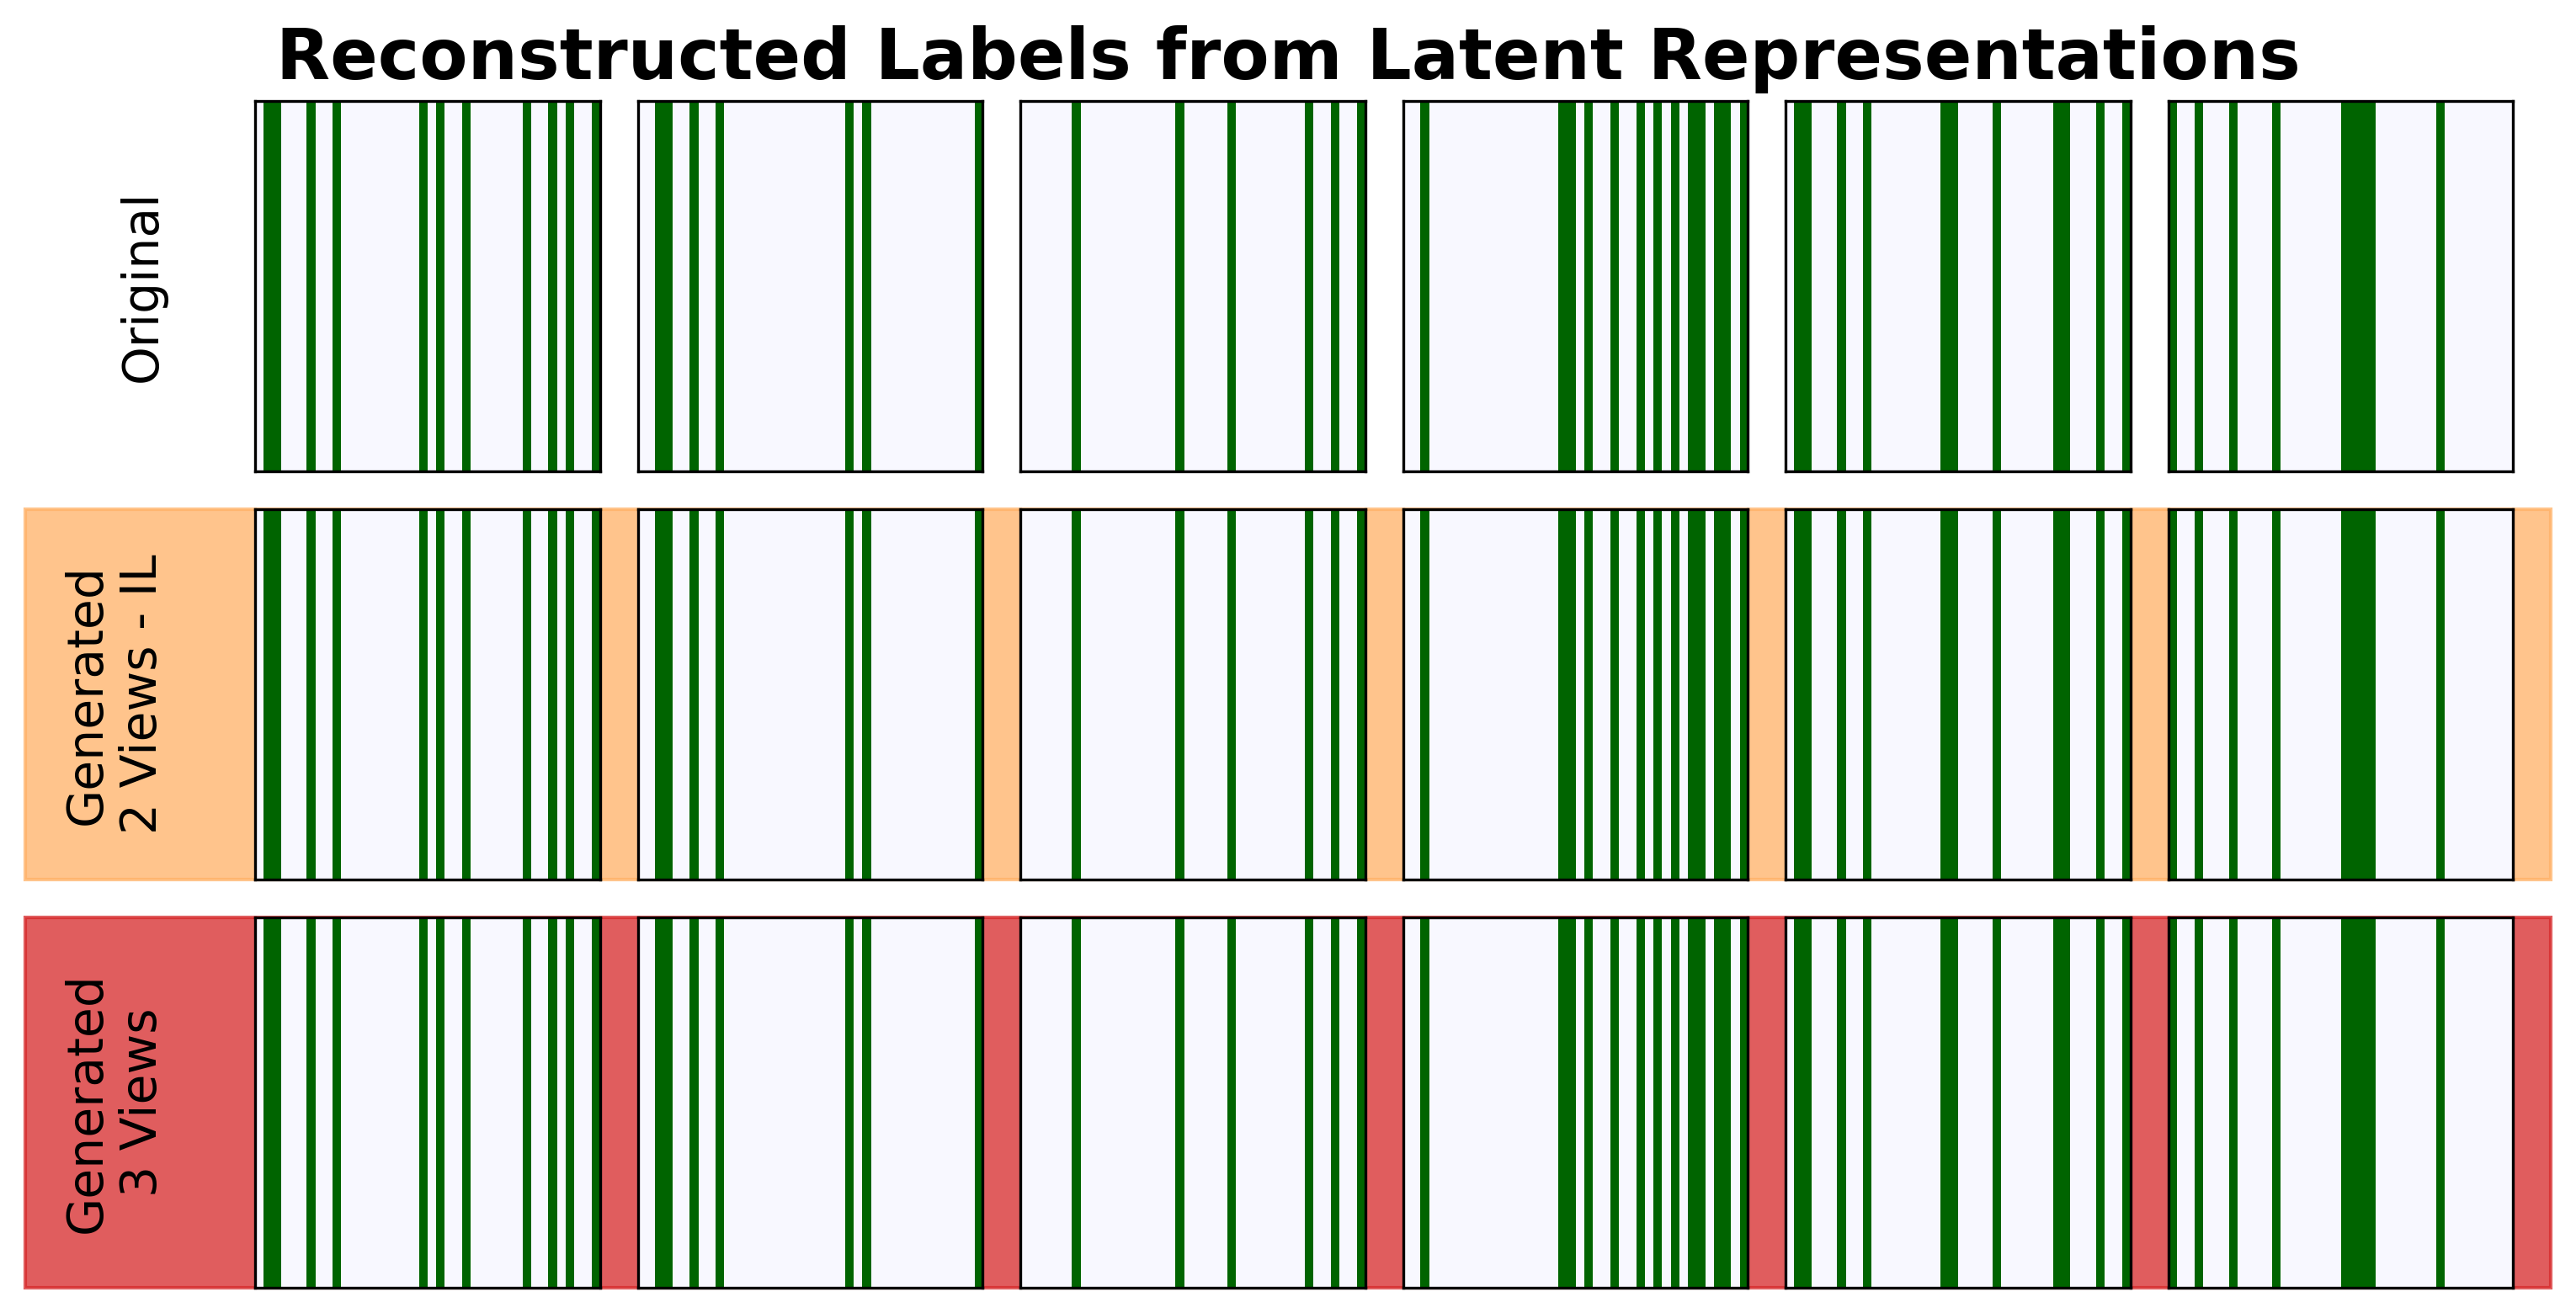

In [40]:
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(3, 6, figsize=(10, 5), dpi=300)

label_sets = [
    all_data_la,
    la_de_2V_IL[0],
    la_de_3V[0]
]

row_colors = [None, '#ffb066', 'tab:red']

row_labels = [
    '\nOriginal',
    'Generated\n2 Views - IL',
    'Generated\n3 Views'
]

cmap = ListedColormap(['ghostwhite', 'darkgreen'])

for i in range(3):
    for j in range(6):
        label_vec = label_sets[i][j].detach().cpu().numpy()

        ax[i, j].imshow(
            label_vec.reshape(1, -1),
            aspect='auto',
            vmin=0,
            vmax=1,
            cmap=cmap
        )

        ax[i, j].set_facecolor('white')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    ax[i, 0].set_ylabel(row_labels[i], fontsize=14, rotation=90, labelpad=40, va='center')

plt.tight_layout()

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

plt.suptitle('Reconstructed Labels from Latent Representations', fontsize=20, fontweight='bold', y=1.03)
plt.savefig('./img/reconstructed_labels_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Disentanglement

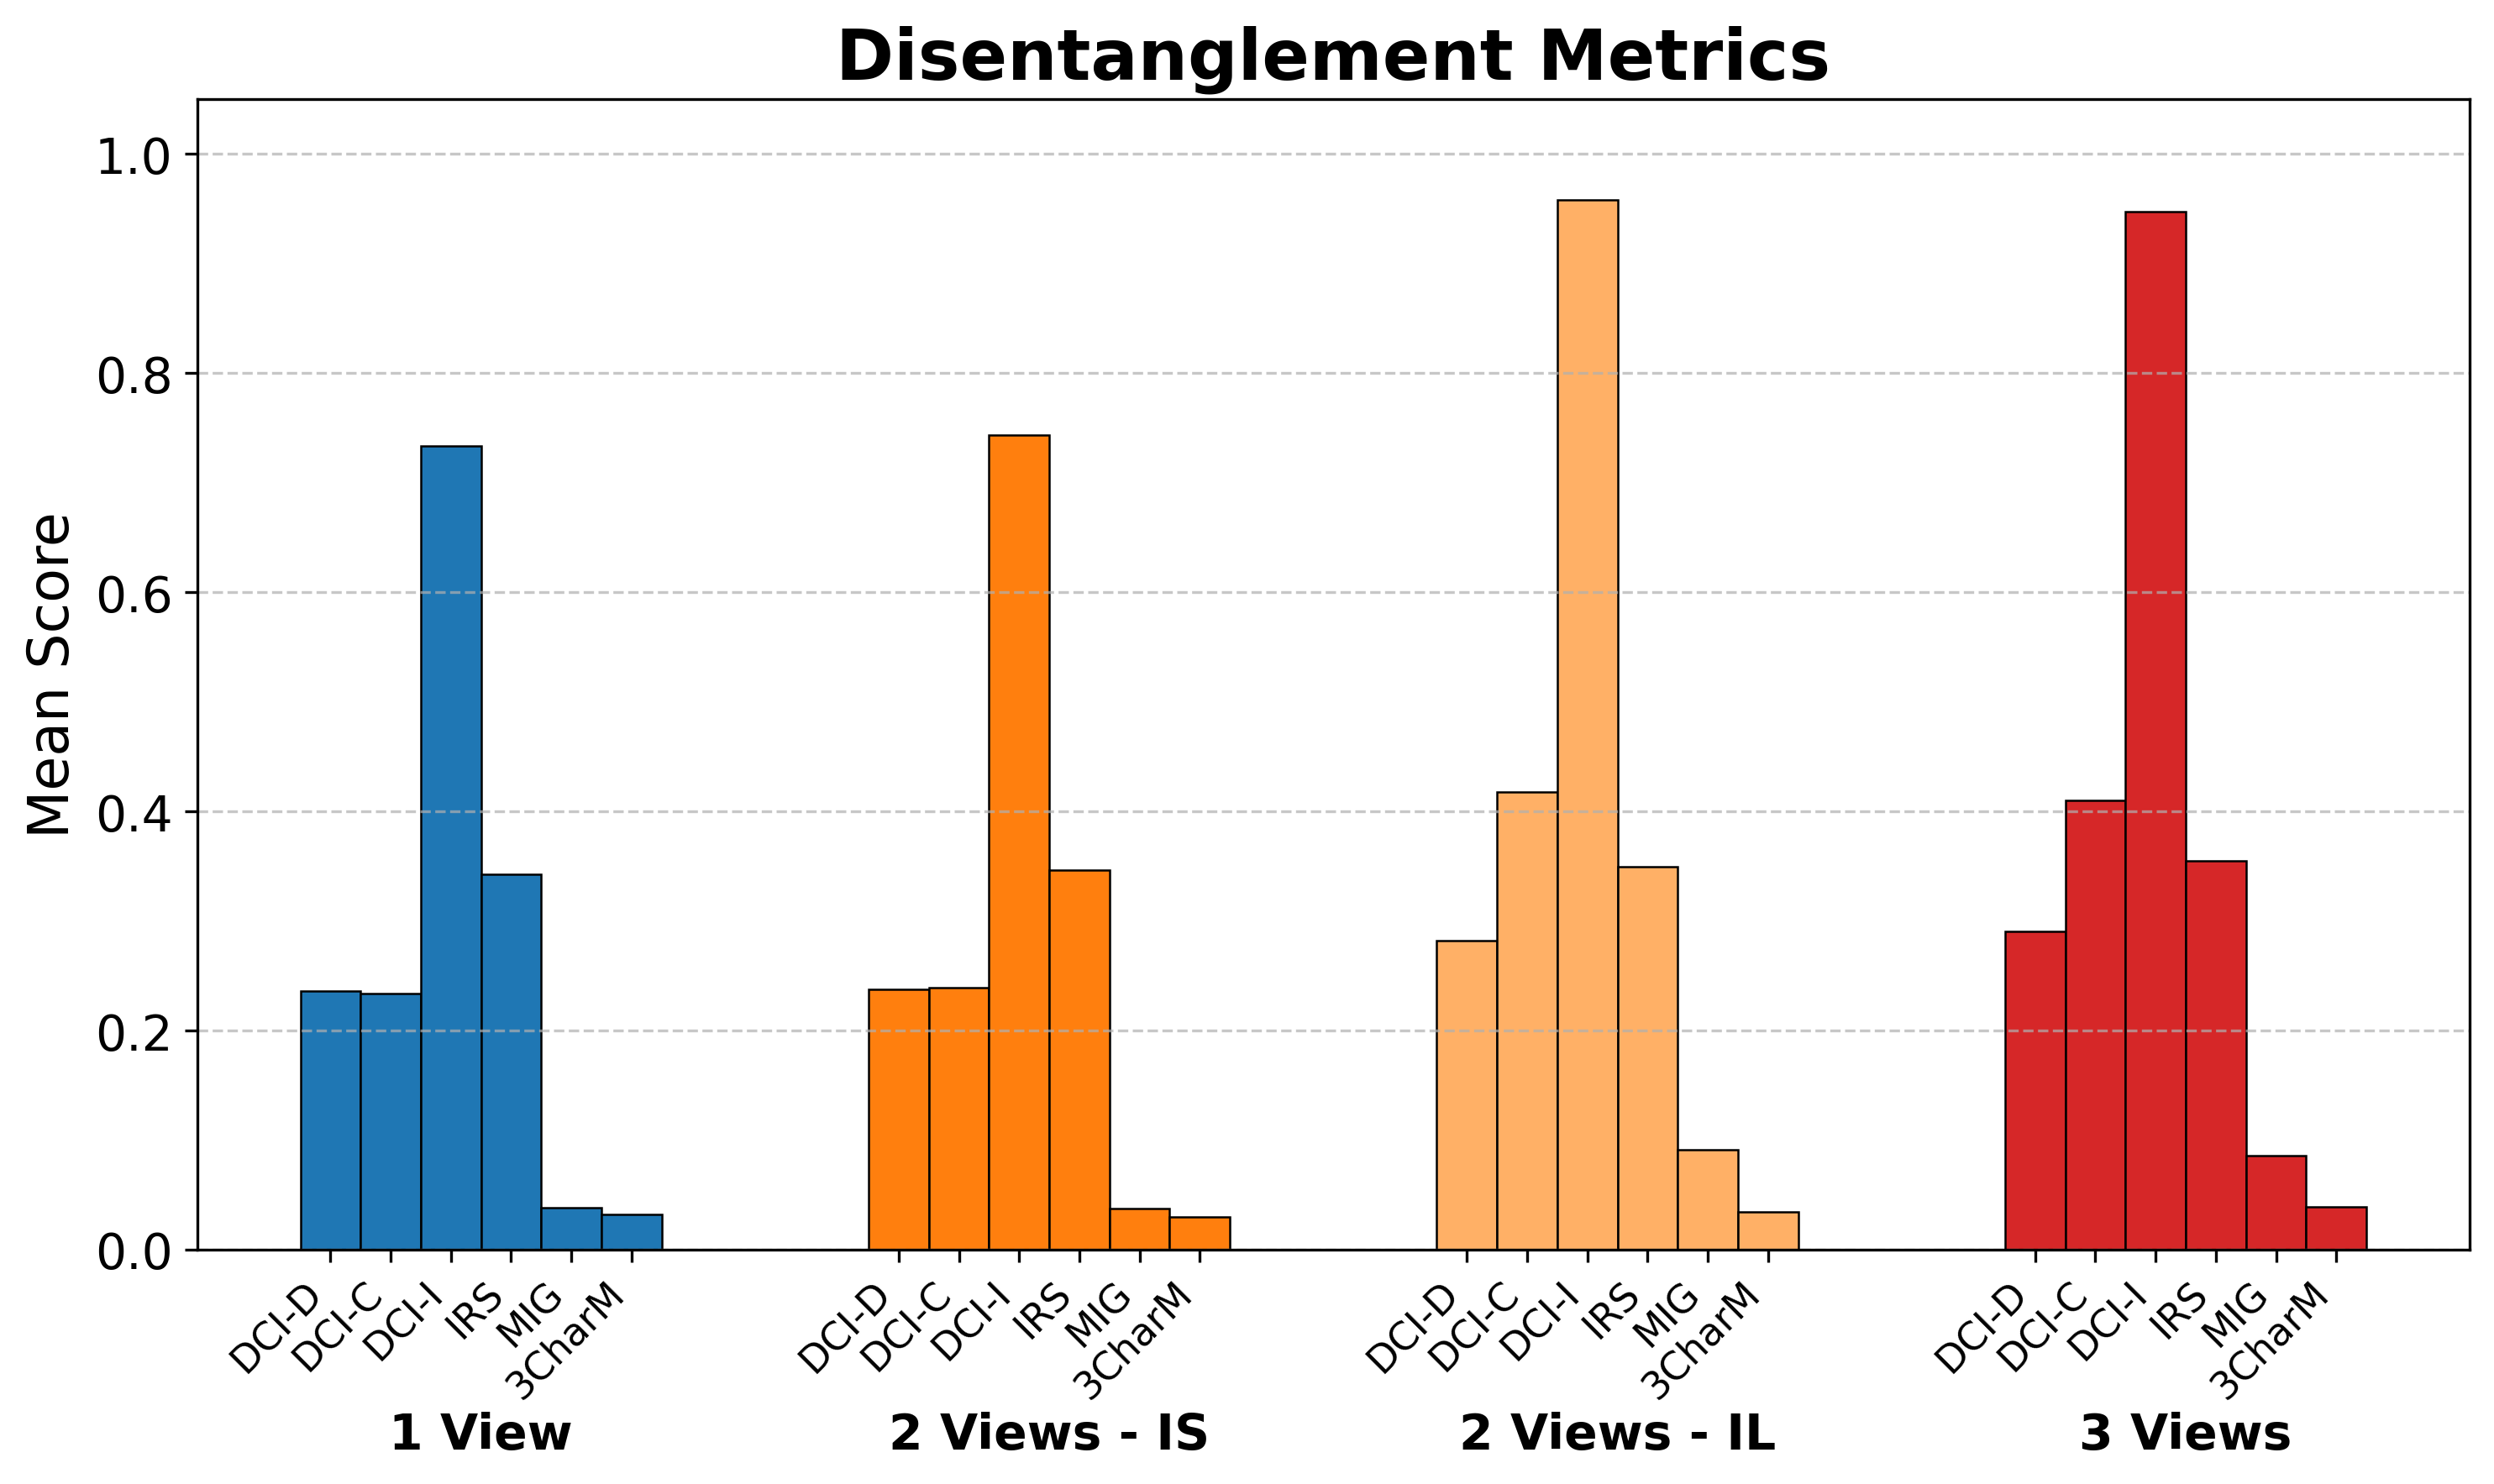

In [41]:
# Model groups
categories = ['1 View', '2 Views - IS', '2 Views - IL', '3 Views']

# Colors depend on the view/model type
model_color_map = {
    '1 View': 'tab:blue',
    '2 Views - IS': 'tab:orange',
    '2 Views - IL': '#ffb066',
    '3 Views': 'tab:red'
}

metric_values = {
    'DCI-D':  [np.mean(np.asarray(v)) for v in [DCI_D_1Vs, DCI_D_2V_ISs, DCI_D_2V_ILs, DCI_D_3Vs]],
    'DCI-C':  [np.mean(np.asarray(v)) for v in [DCI_C_1Vs, DCI_C_2V_ISs, DCI_C_2V_ILs, DCI_C_3Vs]],
    'DCI-I':  [np.mean(np.asarray(v)) for v in [DCI_I_1Vs, DCI_I_2V_ISs, DCI_I_2V_ILs, DCI_I_3Vs]],
    'IRS':    [np.mean(np.asarray(v)) for v in [IRS_1Vs, IRS_2V_ISs, IRS_2V_ILs, IRS_3Vs]],
    'MIG':    [np.mean(np.asarray(v)) for v in [MIG_1Vs, MIG_2V_ISs, MIG_2V_ILs, MIG_3Vs]],
    '3CharM': [np.mean(np.asarray(v)) for v in [TCM_1Vs, TCM_2V_ISs, TCM_2V_ILs, TCM_3Vs]],
}

metrics = list(metric_values.keys())

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.16
group_gap = 0.55

x_positions = []
x_labels = []

for i, category in enumerate(categories):
    group_start = i * (len(metrics) * bar_width + group_gap)

    for j, metric in enumerate(metrics):
        xpos = group_start + j * bar_width
        x_positions.append(xpos)
        x_labels.append(metric)

        ax.bar(
            xpos,
            metric_values[metric][i],
            width=bar_width,
            color=model_color_map[category],
            edgecolor='black',
            linewidth=0.6
        )

# Metric names as x-ticks instead of legend
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)

# Add model labels centered underneath each metric group
group_centers = [
    i * (len(metrics) * bar_width + group_gap) + (len(metrics) - 1) * bar_width / 2
    for i in range(len(categories))
]

for center, category in zip(group_centers, categories):
    ax.text(
        center,
        -0.14,
        category,
        ha='center',
        va='top',
        fontsize=14,
        fontweight='bold',
        transform=ax.get_xaxis_transform()
    )

ax.set_title('Disentanglement Metrics', fontsize=20, fontweight='bold')
ax.set_ylabel('Mean Score', fontsize=16)

ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, 1.05)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./img/disentanglement_metrics_comparison.png', dpi=300)
plt.show()

In [42]:
score_lists = {
    'DCI-D': {
        '1 View': DCI_D_1Vs,
        '2 Views - IS': DCI_D_2V_ISs,
        '2 Views - IL': DCI_D_2V_ILs,
        '3 Views': DCI_D_3Vs,
    },
    'DCI-C': {
        '1 View': DCI_C_1Vs,
        '2 Views - IS': DCI_C_2V_ISs,
        '2 Views - IL': DCI_C_2V_ILs,
        '3 Views': DCI_C_3Vs,
    },
    'DCI-I': {
        '1 View': DCI_I_1Vs,
        '2 Views - IS': DCI_I_2V_ISs,
        '2 Views - IL': DCI_I_2V_ILs,
        '3 Views': DCI_I_3Vs,
    },
    'IRS': {
        '1 View': IRS_1Vs,
        '2 Views - IS': IRS_2V_ISs,
        '2 Views - IL': IRS_2V_ILs,
        '3 Views': IRS_3Vs,
    },
    'MIG': {
        '1 View': MIG_1Vs,
        '2 Views - IS': MIG_2V_ISs,
        '2 Views - IL': MIG_2V_ILs,
        '3 Views': MIG_3Vs,
    },
    '3CharM': {
        '1 View': TCM_1Vs,
        '2 Views - IS': TCM_2V_ISs,
        '2 Views - IL': TCM_2V_ILs,
        '3 Views': TCM_3Vs,
    },
}

alpha = 0.05
rows = []

for metric_name, view_dict in score_lists.items():
    for view_name, values in view_dict.items():
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]

        if len(values) < 3:
            W = np.nan
            p_value = np.nan
            normal = 'Too few samples'
        else:
            W, p_value = stats.shapiro(values)
            normal = 'Yes' if p_value >= alpha else 'No'

        rows.append({
            'Metric': metric_name,
            'View': view_name,
            'n': len(values),
            'Mean': np.mean(values) if len(values) > 0 else np.nan,
            'Std': np.std(values, ddof=1) if len(values) > 1 else np.nan,
            'Shapiro W': W,
            'p-value': p_value,
            'Normal at α=0.05': normal
        })

shapiro_results = pd.DataFrame(rows)

shapiro_results

,Metric,View,n,Mean,Std,Shapiro W,p-value,Normal at α=0.05
0,DCI-D,1 View,10,0.236142,0.012244,0.948480,0.650545,Yes
1,DCI-D,2 Views - IS,10,0.238020,0.008314,0.917962,0.340267,Yes
2,DCI-D,2 Views - IL,10,0.282122,0.017069,0.935078,0.499654,Yes
3,DCI-D,3 Views,10,0.290891,0.008167,0.954728,0.724500,Yes
4,DCI-C,1 View,10,0.233794,0.013005,0.980988,0.970237,Yes
5,DCI-C,2 Views - IS,10,0.239594,0.010313,0.961582,0.803756,Yes
6,DCI-C,2 Views - IL,10,0.417876,0.018889,0.905006,0.248415,Yes
7,DCI-C,3 Views,10,0.409974,0.010418,0.958400,0.767485,Yes
8,DCI-I,1 View,10,0.733822,0.028102,0.987150,0.991990,Yes
9,DCI-I,2 Views - IS,10,0.743882,0.017193,0.898106,0.208823,Yes


In [43]:
alpha = 0.05
rows = []

for metric_name, view_dict in score_lists.items():
    groups = []
    group_names = []

    for view_name, values in view_dict.items():
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]

        if len(values) > 1:
            groups.append(values)
            group_names.append(view_name)

    if len(groups) == 4:
        F_stat, p_value = f_oneway(*groups)

        rows.append({
            'Metric': metric_name,
            'Groups': ', '.join(group_names),
            'F-statistic': F_stat,
            'p-value': p_value,
            'Significant at α=0.05': 'Yes' if p_value < alpha else 'No'
        })
    else:
        rows.append({
            'Metric': metric_name,
            'Groups': ', '.join(group_names),
            'F-statistic': np.nan,
            'p-value': np.nan,
            'Significant at α=0.05': 'Too few valid groups'
        })

anova_results = pd.DataFrame(rows)

anova_results

,Metric,Groups,F-statistic,p-value,Significant at α=0.05
0,DCI-D,"1 View, 2 Views - IS, 2 Views - IL, 3 Views",57.367314,8.601540e-14,Yes
1,DCI-C,"1 View, 2 Views - IS, 2 Views - IL, 3 Views",566.198609,2.469099e-30,Yes
2,DCI-I,"1 View, 2 Views - IS, 2 Views - IL, 3 Views",490.123203,3.123771e-29,Yes
3,IRS,"1 View, 2 Views - IS, 2 Views - IL, 3 Views",1.140015,3.460155e-01,No
4,MIG,"1 View, 2 Views - IS, 2 Views - IL, 3 Views",84.180721,2.462270e-16,Yes
5,3CharM,"1 View, 2 Views - IS, 2 Views - IL, 3 Views",3.445938,2.662593e-02,Yes


In [44]:
alpha = 0.05

for metric_name, view_dict in score_lists.items():
    df_metric = []

    for view_name, values in view_dict.items():
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]

        for value in values:
            df_metric.append({
                'View': view_name,
                'Score': value
            })

    df_metric = pd.DataFrame(df_metric)

    tukey_results = sp.posthoc_tukey(
        df_metric,
        val_col='Score',
        group_col='View'
    )

    cld = sp.compact_letter_display(tukey_results)

    print(f'\n===== {metric_name} =====')
    print(cld)


===== DCI-D =====
1 View          a 
2 Views - IS    a 
2 Views - IL     b
3 Views          b
Name: letters, dtype: object

===== DCI-C =====
1 View          a 
2 Views - IS    a 
2 Views - IL     b
3 Views          b
Name: letters, dtype: object

===== DCI-I =====
1 View          a 
2 Views - IS    a 
2 Views - IL     b
3 Views          b
Name: letters, dtype: object

===== IRS =====
1 View          a
2 Views - IS    a
2 Views - IL    a
3 Views         a
Name: letters, dtype: object

===== MIG =====
1 View          a 
2 Views - IS    a 
2 Views - IL     b
3 Views          b
Name: letters, dtype: object

===== 3CharM =====
1 View          ab
2 Views - IS     b
2 Views - IL    ab
3 Views         a 
Name: letters, dtype: object
